# Problem Statement

Within the context of human resources (HR), attrition is a reduction in the workforce caused by retirement or resignation. This is a serious problem faced by several organizations around the world as attrition is economically damaging to the organizations as the replacement employees have to be hired at a cost and trained again at a cost. High Rates of Attrition also damage the brand value of the company.
 
Now the Dataset belongs to a very fast-growing company. This company has witnessed several employees leaving the company in the last 3 years. The company’s HR team has always been reactive to attrition but now the team wants to be proactive and wishes to predict the attrition of employees using the data they have in hand. 
 
The goal here is to predict whether an employee will leave the company based on the various variables given in the dataset.

# Dataset Information

Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EmployeeID          5180 non-null   float64
 1   Attrition           5180 non-null   float64
 2   Age                 4864 non-null   float64
 3   TravelProfile       5180 non-null   object 
 4   Department          5056 non-null   object 
 5   HomeToWork          4925 non-null   float64
 6   EducationField      5180 non-null   object 
 7   Gender              5134 non-null   object 
 8   HourlnWeek          4893 non-null   float64
 9   Involvement         5180 non-null   float64
 10  WorkLifeBalance     5180 non-null   float64
 11  Designation         5142 non-null   object 
 12  JobSatisfaction     5180 non-null   float64
 13  ESOPs               5180 non-null   float64
 14  NumCompaniesWorked  5180 non-null   float64
 15  OverTime            5180 non-null   float64
 16  SalaryHikelastYear  5011 non-null   float64
 17  WorkExperience      4993 non-null   float64
 18  LastPromotion       5110 non-null   float64
 19  CurrentProfile      4869 non-null   float64
 20  MaritalStatus       5180 non-null   object 
 21  MonthlyIncome       5087 non-null   float64

In [1]:
# import libraries

# import 'Pandas'
import pandas as pd

# import 'Numpy'
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt

# import 'Seaborn'
import seaborn as sns

# to suppress warnings
from warnings import filterwarnings
filterwarnings('ignore')

# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None

# to display the float values upto 6 decimal places
pd.options.display.float_format = '{:.6f}'.format

# import train-test split
from sklearn.model_selection import train_test_split

# import StandardScaler to perform scaling
from sklearn.preprocessing import StandardScaler

# import various functions from sklearn
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV

# import the functions for visualizing the decision tree
import pydotplus
from IPython.display import Image

In [2]:
# set the plot size using 'rcParams'
# once the plot size is set using 'rcParams', it sets the size of all the forthcoming plots in the file
# pass width and height in inches to 'figure.figsize'
plt.rcParams['figure.figsize'] = [15,8]

# Data Preparation

In [3]:
# Read the training data

data = pd.read_csv("Train_Dataset.csv")

data.head()

,EmployeeID,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,WorkLifeBalance,Designation,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
0,5110001.000000,0.000000,35.000000,Rarely,Analytics,5.000000,CA,Male,69.000000,1.000000,1.000000,Executive,1.000000,1.000000,1.000000,1.000000,20.000000,7.000000,2.000000,NaN,M,18932.000000
1,5110002.000000,1.000000,32.000000,Yes,Sales,5.000000,Statistics,Female,62.000000,4.000000,3.000000,Executive,2.000000,0.000000,8.000000,0.000000,20.000000,4.000000,1.000000,NaN,Single,18785.000000
2,5110003.000000,0.000000,31.000000,Rarely,Analytics,5.000000,Statistics,F,45.000000,5.000000,3.000000,Manager,2.000000,1.000000,3.000000,0.000000,26.000000,12.000000,1.000000,3.000000,Single,22091.000000
3,5110004.000000,0.000000,34.000000,Yes,Sales,10.000000,Statistics,Female,32.000000,3.000000,2.000000,Manager,4.000000,1.000000,1.000000,0.000000,23.000000,5.000000,1.000000,3.000000,Divorsed,20302.000000
4,5110005.000000,0.000000,37.000000,No,Analytics,27.000000,Statistics,Female,49.000000,3.000000,4.000000,Manager,4.000000,1.000000,8.000000,0.000000,21.000000,12.000000,1.000000,9.000000,Divorsed,21674.000000


In [4]:
# get the no. of rows and columns

data.shape

(7810, 22)

In [5]:
data.tail()

,EmployeeID,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,WorkLifeBalance,Designation,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
7805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
data_truncated = data.iloc[:5180]

data_truncated.head()

,EmployeeID,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,WorkLifeBalance,Designation,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
0,5110001.000000,0.000000,35.000000,Rarely,Analytics,5.000000,CA,Male,69.000000,1.000000,1.000000,Executive,1.000000,1.000000,1.000000,1.000000,20.000000,7.000000,2.000000,NaN,M,18932.000000
1,5110002.000000,1.000000,32.000000,Yes,Sales,5.000000,Statistics,Female,62.000000,4.000000,3.000000,Executive,2.000000,0.000000,8.000000,0.000000,20.000000,4.000000,1.000000,NaN,Single,18785.000000
2,5110003.000000,0.000000,31.000000,Rarely,Analytics,5.000000,Statistics,F,45.000000,5.000000,3.000000,Manager,2.000000,1.000000,3.000000,0.000000,26.000000,12.000000,1.000000,3.000000,Single,22091.000000
3,5110004.000000,0.000000,34.000000,Yes,Sales,10.000000,Statistics,Female,32.000000,3.000000,2.000000,Manager,4.000000,1.000000,1.000000,0.000000,23.000000,5.000000,1.000000,3.000000,Divorsed,20302.000000
4,5110005.000000,0.000000,37.000000,No,Analytics,27.000000,Statistics,Female,49.000000,3.000000,4.000000,Manager,4.000000,1.000000,8.000000,0.000000,21.000000,12.000000,1.000000,9.000000,Divorsed,21674.000000


In [7]:
data_truncated.shape

(5180, 22)

In [8]:
data_truncated.tail()

,EmployeeID,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,WorkLifeBalance,Designation,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
5175,5115176.000000,0.000000,36.000000,Rarely,Analytics,13.000000,CA,F,53.000000,3.000000,3.000000,Manager,3.000000,0.000000,4.000000,1.000000,22.000000,11.000000,1.000000,5.000000,Single,22142.000000
5176,5115177.000000,0.000000,NaN,Rarely,Marketing,9.000000,CA,Female,66.000000,1.000000,4.000000,Executive,4.000000,1.000000,9.000000,0.000000,23.000000,8.000000,0.000000,2.000000,Single,17109.000000
5177,5115178.000000,0.000000,29.000000,Rarely,Analytics,NaN,CA,Female,62.000000,4.000000,2.000000,Executive,1.000000,1.000000,6.000000,0.000000,19.000000,8.000000,0.000000,3.000000,M,17532.000000
5178,5115179.000000,0.000000,26.000000,Rarely,Marketing,26.000000,Statistics,Female,61.000000,3.000000,4.000000,Executive,3.000000,0.000000,1.000000,0.000000,28.000000,8.000000,5.000000,7.000000,Divorsed,17942.000000
5179,5115180.000000,1.000000,NaN,Yes,Sales,13.000000,Statistics,Male,74.000000,4.000000,3.000000,Executive,5.000000,1.000000,1.000000,0.000000,23.000000,1.000000,0.000000,0.000000,Divorsed,17033.000000


In [9]:
df = data_truncated.copy()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5180 entries, 0 to 5179
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EmployeeID          5180 non-null   float64
 1   Attrition           5180 non-null   float64
 2   Age                 4864 non-null   float64
 3   TravelProfile       5180 non-null   object 
 4   Department          5056 non-null   object 
 5   HomeToWork          4925 non-null   float64
 6   EducationField      5180 non-null   object 
 7   Gender              5134 non-null   object 
 8   HourlnWeek          4893 non-null   float64
 9   Involvement         5180 non-null   float64
 10  WorkLifeBalance     5180 non-null   float64
 11  Designation         5142 non-null   object 
 12  JobSatisfaction     5180 non-null   float64
 13  ESOPs               5180 non-null   float64
 14  NumCompaniesWorked  5180 non-null   float64
 15  OverTime            5180 non-null   float64
 16  Salary

# Change the Data Type of Attrition

In [10]:
# convert numerical variables to categorical (object)
# use astype() to change the data type

# change the data type of 'Attrition'
df['Attrition'] = df['Attrition'].astype(object)

In [11]:
# check the data types

df.dtypes

EmployeeID            float64
Attrition              object
Age                   float64
TravelProfile          object
Department             object
HomeToWork            float64
EducationField         object
Gender                 object
HourlnWeek            float64
Involvement           float64
WorkLifeBalance       float64
Designation            object
JobSatisfaction       float64
ESOPs                 float64
NumCompaniesWorked    float64
OverTime              float64
SalaryHikelastYear    float64
WorkExperience        float64
LastPromotion         float64
CurrentProfile        float64
MaritalStatus          object
MonthlyIncome         float64
dtype: object

In [12]:
# ESOPs seem to be a boolean data. Let's check the unique value

unique_esops = df['ESOPs'].unique()

unique_esops

array([1., 0.])

In [13]:
# convert numerical variables to categorical (object)
# use astype() to change the data type

# change the data type of 'ESOPs'
df['ESOPs'] = df['ESOPs'].astype(object)

df.dtypes

EmployeeID            float64
Attrition              object
Age                   float64
TravelProfile          object
Department             object
HomeToWork            float64
EducationField         object
Gender                 object
HourlnWeek            float64
Involvement           float64
WorkLifeBalance       float64
Designation            object
JobSatisfaction       float64
ESOPs                  object
NumCompaniesWorked    float64
OverTime              float64
SalaryHikelastYear    float64
WorkExperience        float64
LastPromotion         float64
CurrentProfile        float64
MaritalStatus          object
MonthlyIncome         float64
dtype: object

# Remove Insignificant Variables

EmployeeID is insignificant for our analysis, dropping

In [14]:
df = df.drop('EmployeeID', axis = 1)

df.head()

,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,WorkLifeBalance,Designation,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
0,0.000000,35.000000,Rarely,Analytics,5.000000,CA,Male,69.000000,1.000000,1.000000,Executive,1.000000,1.000000,1.000000,1.000000,20.000000,7.000000,2.000000,NaN,M,18932.000000
1,1.000000,32.000000,Yes,Sales,5.000000,Statistics,Female,62.000000,4.000000,3.000000,Executive,2.000000,0.000000,8.000000,0.000000,20.000000,4.000000,1.000000,NaN,Single,18785.000000
2,0.000000,31.000000,Rarely,Analytics,5.000000,Statistics,F,45.000000,5.000000,3.000000,Manager,2.000000,1.000000,3.000000,0.000000,26.000000,12.000000,1.000000,3.000000,Single,22091.000000
3,0.000000,34.000000,Yes,Sales,10.000000,Statistics,Female,32.000000,3.000000,2.000000,Manager,4.000000,1.000000,1.000000,0.000000,23.000000,5.000000,1.000000,3.000000,Divorsed,20302.000000
4,0.000000,37.000000,No,Analytics,27.000000,Statistics,Female,49.000000,3.000000,4.000000,Manager,4.000000,1.000000,8.000000,0.000000,21.000000,12.000000,1.000000,9.000000,Divorsed,21674.000000


In [15]:
# shape of the data

df.shape

(5180, 21)

**Missing Value Checks and Treatments**

In [16]:
df.isnull().sum()

Attrition               0
Age                   316
TravelProfile           0
Department            124
HomeToWork            255
EducationField          0
Gender                 46
HourlnWeek            287
Involvement             0
WorkLifeBalance         0
Designation            38
JobSatisfaction         0
ESOPs                   0
NumCompaniesWorked      0
OverTime                0
SalaryHikelastYear    169
WorkExperience        187
LastPromotion          70
CurrentProfile        311
MaritalStatus           0
MonthlyIncome          93
dtype: int64

In [17]:
# 5 point summary for numeric and object columns

df.describe()

,Age,HomeToWork,HourlnWeek,Involvement,WorkLifeBalance,JobSatisfaction,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MonthlyIncome
count,4864.000000,4925.000000,4893.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5011.000000,4993.000000,5110.000000,4869.000000,5087.000000
mean,37.108553,11.107411,57.979767,3.226641,3.012741,3.144402,3.157336,0.313514,20.649371,11.165832,2.552838,4.385295,21692.296442
std,9.248647,8.455577,12.996674,0.872431,1.410602,1.342776,2.606036,0.463966,3.706469,7.797783,3.234467,3.617643,4770.637922
min,18.000000,1.000000,10.000000,1.000000,1.000000,1.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,1000.000000
25%,30.000000,5.000000,49.000000,3.000000,2.000000,2.000000,1.000000,0.000000,18.000000,6.000000,1.000000,2.000000,18362.000000
50%,36.000000,9.000000,59.000000,3.000000,3.000000,3.000000,2.000000,0.000000,20.000000,9.000000,1.000000,3.000000,20160.000000
75%,43.000000,16.000000,67.000000,4.000000,4.000000,4.000000,5.000000,1.000000,23.000000,15.000000,3.000000,7.000000,23443.500000
max,61.000000,121.000000,99.000000,5.000000,5.000000,5.000000,21.000000,1.000000,31.000000,41.000000,16.000000,18.000000,95000.000000


In [18]:
df.describe(include='object')

,Attrition,TravelProfile,Department,EducationField,Gender,Designation,ESOPs,MaritalStatus
count,5180.000000,5180,5056,5180,5134,5142,5180.000000,5180
unique,2.000000,3,3,6,3,5,2.000000,4
top,0.000000,Rarely,Analytics,Statistics,Male,Executive,0.000000,Single
freq,3735.000000,3637,3219,2129,3094,2072,2639.000000,1776


**Inference**

There are missing values in few columns like Age, Department, HometoWork Gender etc.


# Data Distributions

**Target Column Data Distribution**

Count (Bar) plot

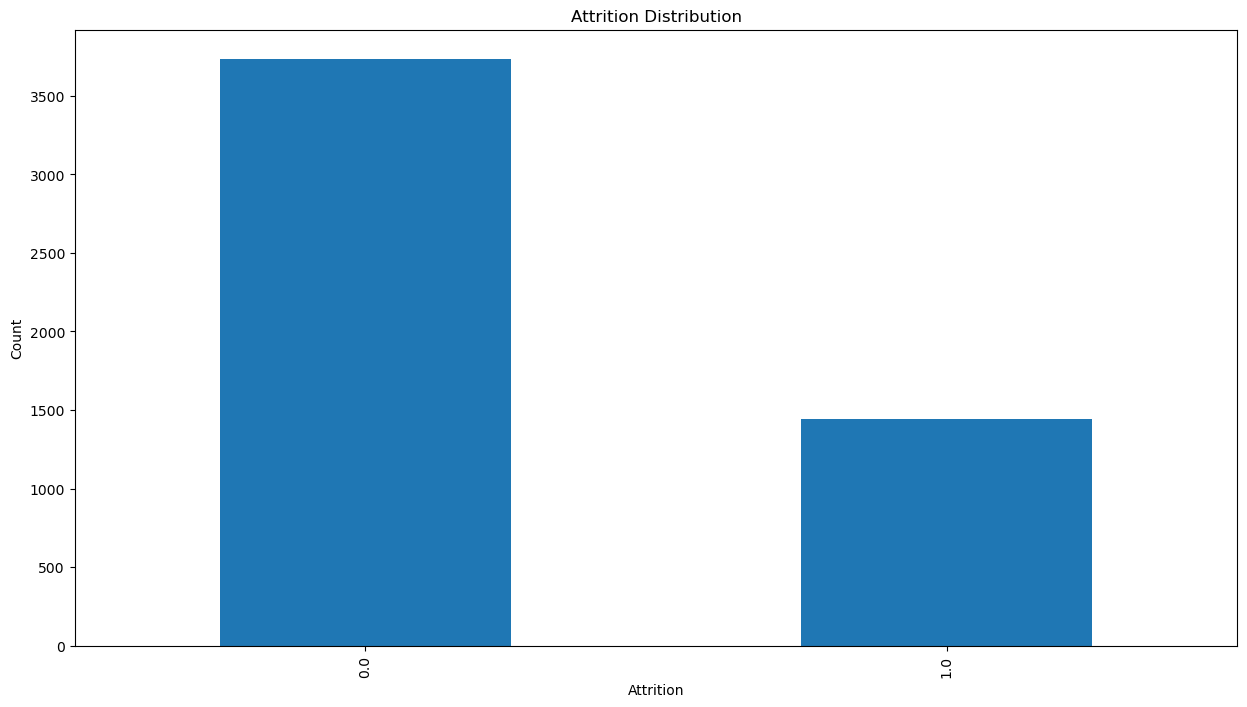

In [19]:
df['Attrition'].value_counts().plot(kind='bar')

plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')

plt.show()

**Inference**

Data is imbalanced as class 1 is way less that class 0.

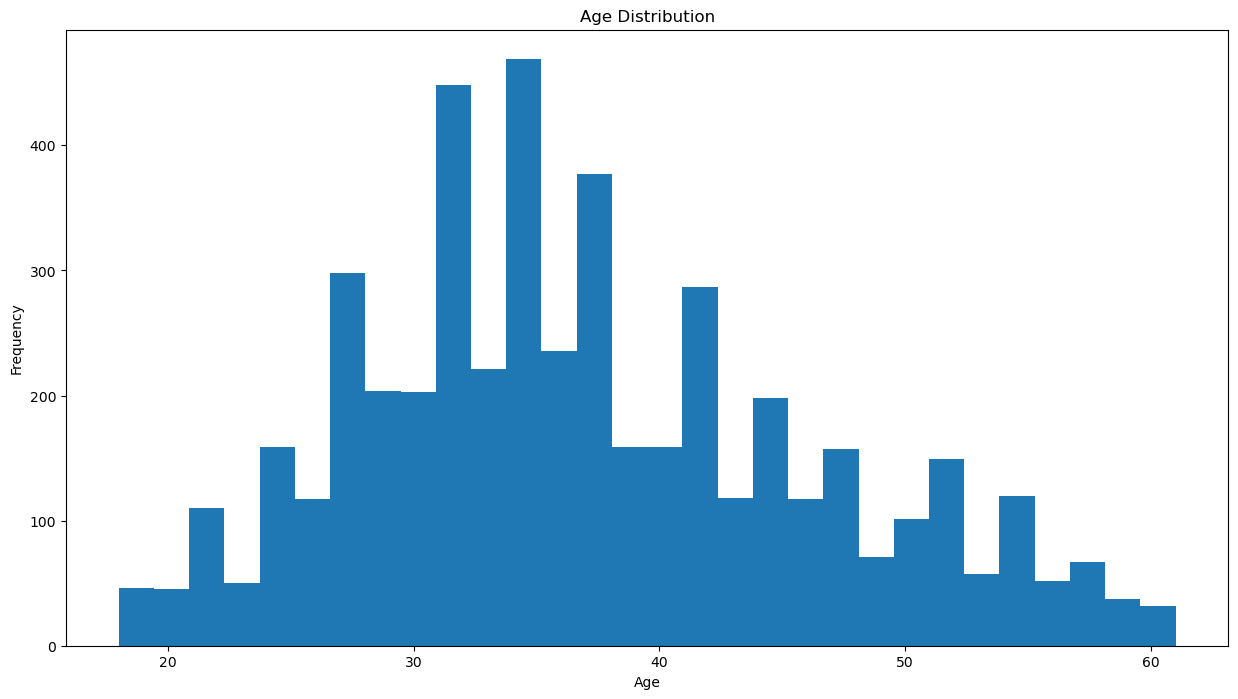

In [20]:
# Numerical Data Distribution

plt.hist(df['Age'].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


**Inference**

Data seems to be normally distributed and younger employees tend to leave 

# Income vs Attrition 

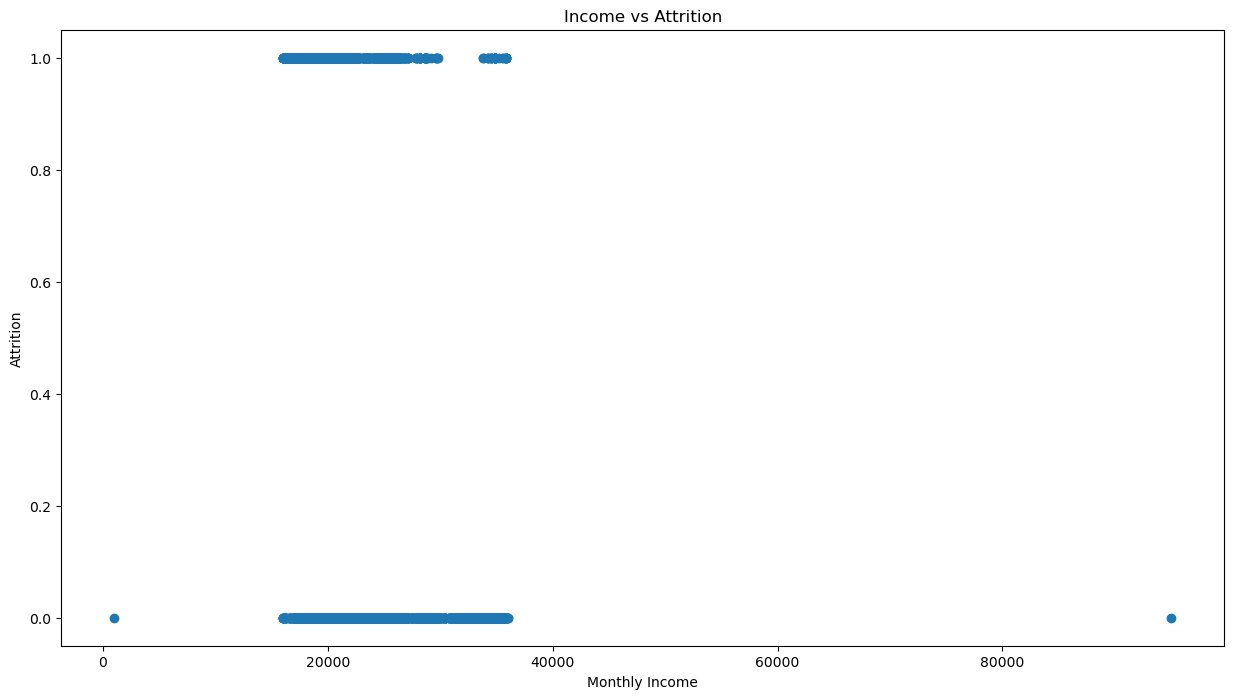

In [21]:
plt.scatter(df['MonthlyIncome'], df['Attrition'])
plt.title("Income vs Attrition")
plt.xlabel("Monthly Income")
plt.ylabel("Attrition")
plt.show()


**Inference**

Lower Salary employees - high risk of attirition


# Correlation Heatmap

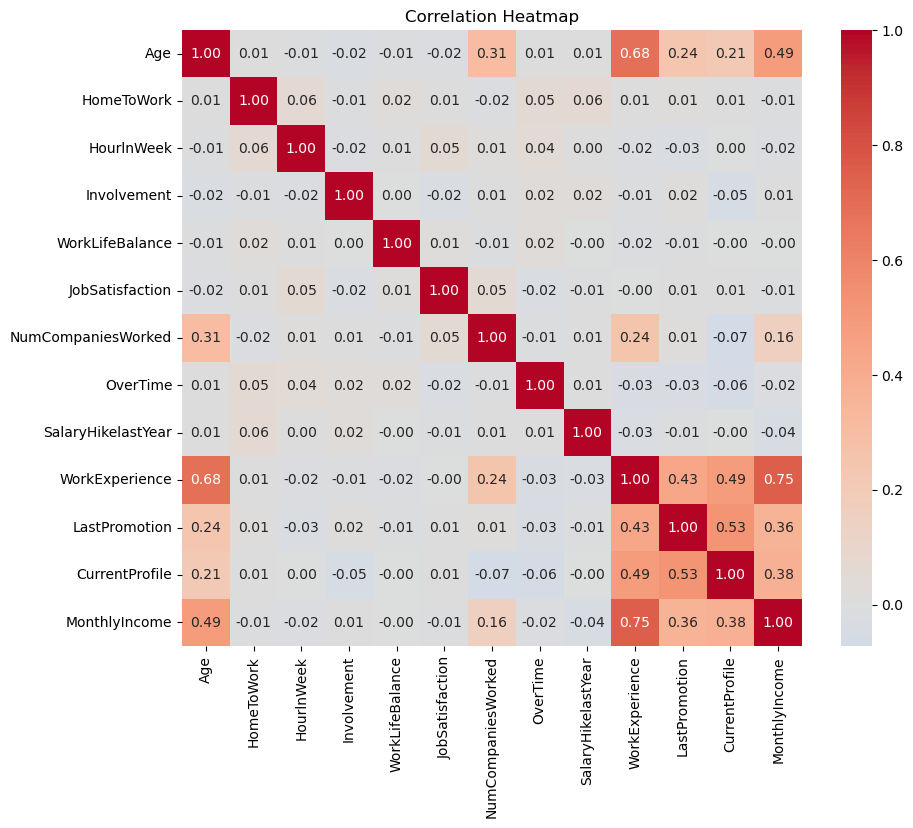

In [22]:
#Correlation of numerical columns

corr_matrix = df.select_dtypes(include='number').corr()

#Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       # Shows the correlation values in each cell
            fmt=".2f",        # Rounds values to 2 decimal places
            cmap='coolwarm',  # Best for correlation (Red=Positive, Blue=Negative)
            center=0)         # Ensures 0 is the neutral color

plt.title("Correlation Heatmap")
plt.show()

**Inference**

Age, MonthlyIncome and WorkExperience are highly correlated 

In [23]:
df.isnull().sum()

Attrition               0
Age                   316
TravelProfile           0
Department            124
HomeToWork            255
EducationField          0
Gender                 46
HourlnWeek            287
Involvement             0
WorkLifeBalance         0
Designation            38
JobSatisfaction         0
ESOPs                   0
NumCompaniesWorked      0
OverTime                0
SalaryHikelastYear    169
WorkExperience        187
LastPromotion          70
CurrentProfile        311
MaritalStatus           0
MonthlyIncome          93
dtype: int64

# Missing  Value Treatment

In [24]:
# Numerical → median

num_cols = df.select_dtypes(include='number').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → mode

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [25]:
# check missing data


df.isnull().sum()

Attrition             0
Age                   0
TravelProfile         0
Department            0
HomeToWork            0
EducationField        0
Gender                0
HourlnWeek            0
Involvement           0
WorkLifeBalance       0
Designation           0
JobSatisfaction       0
ESOPs                 0
NumCompaniesWorked    0
OverTime              0
SalaryHikelastYear    0
WorkExperience        0
LastPromotion         0
CurrentProfile        0
MaritalStatus         0
MonthlyIncome         0
dtype: int64

**Inference**

No Missing Data

In [26]:
# Fixing the inconsistency

df['Gender'] = df['Gender'].replace({'M':'Male','F':'Female'})

df.head()


,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,WorkLifeBalance,Designation,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
0,0.000000,35.000000,Rarely,Analytics,5.000000,CA,Male,69.000000,1.000000,1.000000,Executive,1.000000,1.000000,1.000000,1.000000,20.000000,7.000000,2.000000,3.000000,M,18932.000000
1,1.000000,32.000000,Yes,Sales,5.000000,Statistics,Female,62.000000,4.000000,3.000000,Executive,2.000000,0.000000,8.000000,0.000000,20.000000,4.000000,1.000000,3.000000,Single,18785.000000
2,0.000000,31.000000,Rarely,Analytics,5.000000,Statistics,Female,45.000000,5.000000,3.000000,Manager,2.000000,1.000000,3.000000,0.000000,26.000000,12.000000,1.000000,3.000000,Single,22091.000000
3,0.000000,34.000000,Yes,Sales,10.000000,Statistics,Female,32.000000,3.000000,2.000000,Manager,4.000000,1.000000,1.000000,0.000000,23.000000,5.000000,1.000000,3.000000,Divorsed,20302.000000
4,0.000000,37.000000,No,Analytics,27.000000,Statistics,Female,49.000000,3.000000,4.000000,Manager,4.000000,1.000000,8.000000,0.000000,21.000000,12.000000,1.000000,9.000000,Divorsed,21674.000000


# Outlier Detection


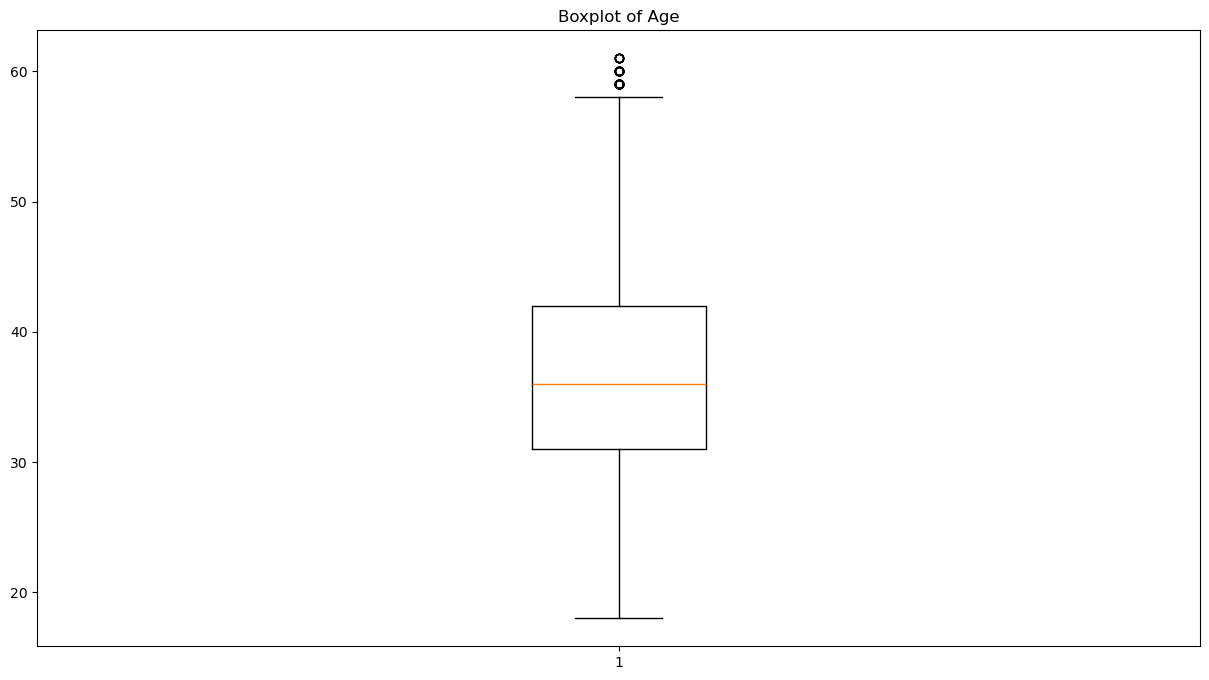

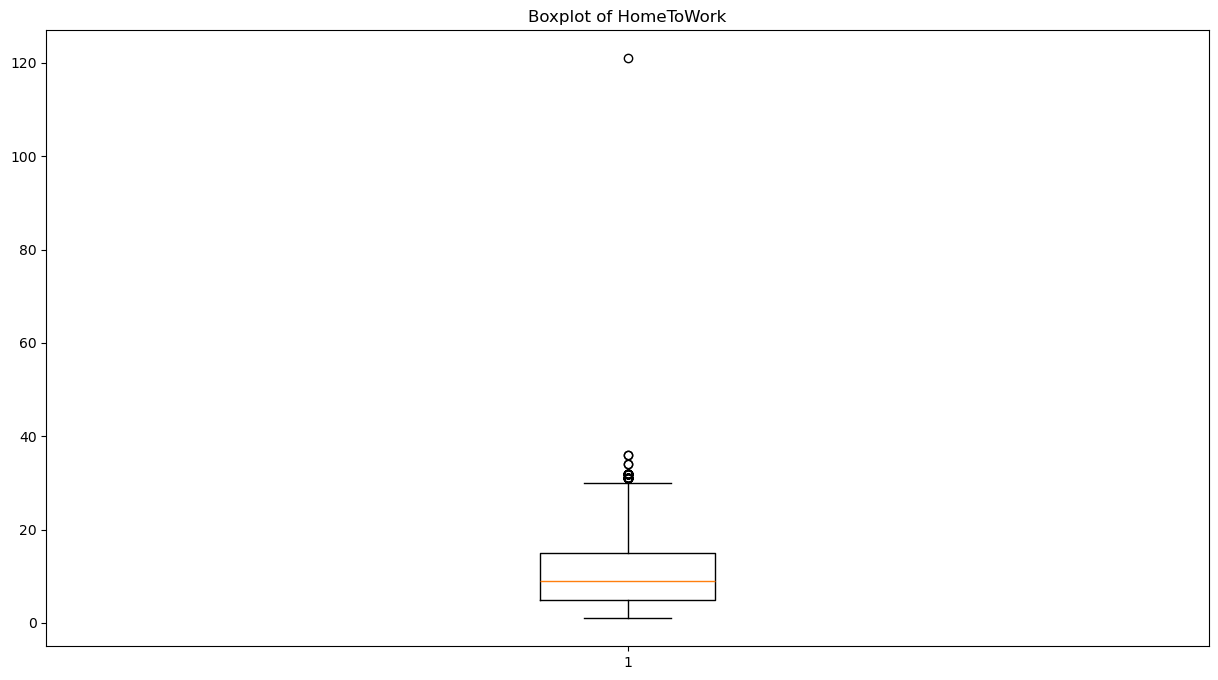

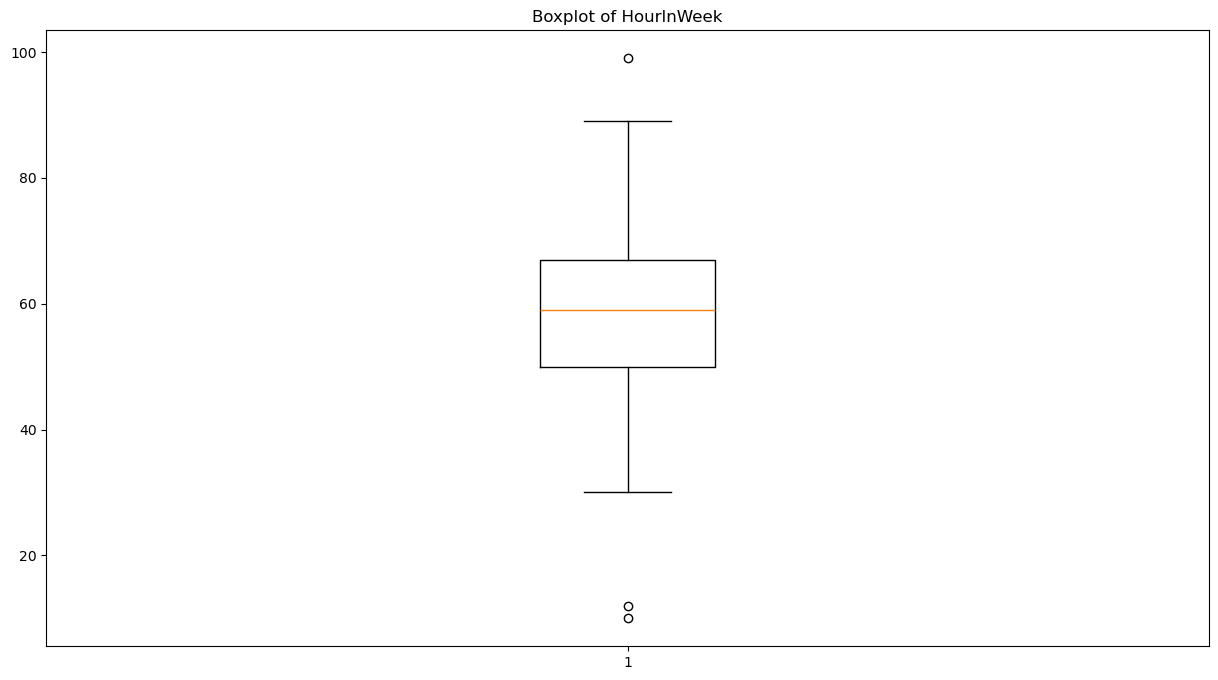

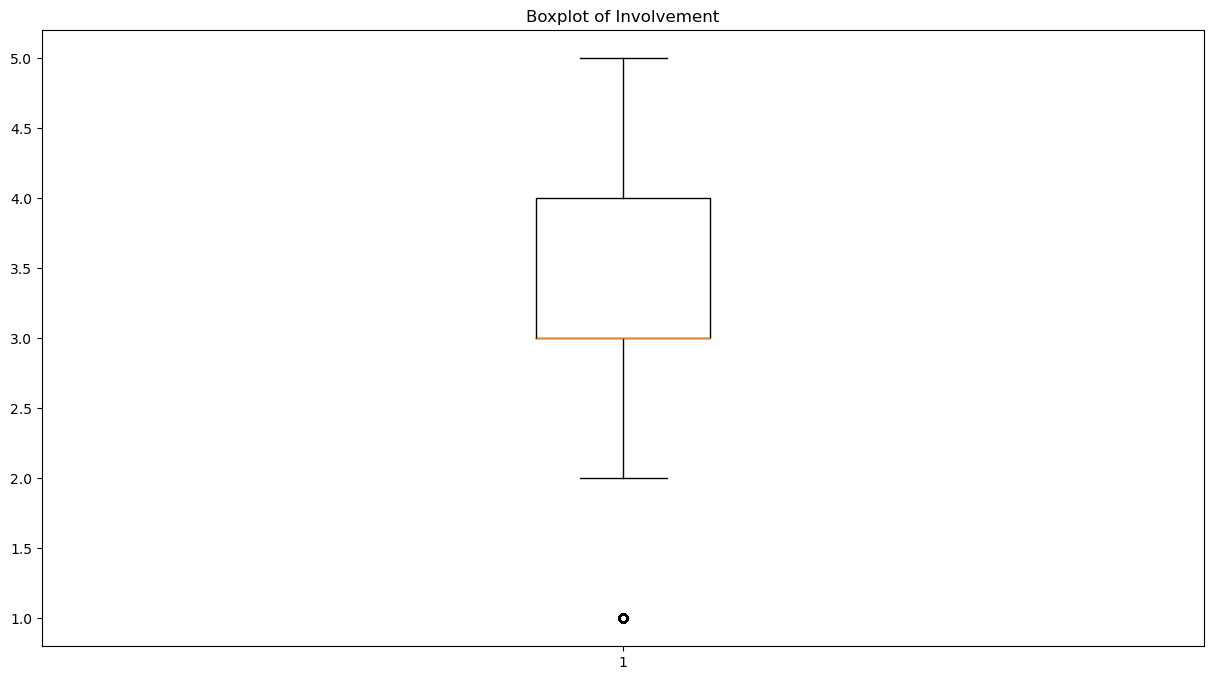

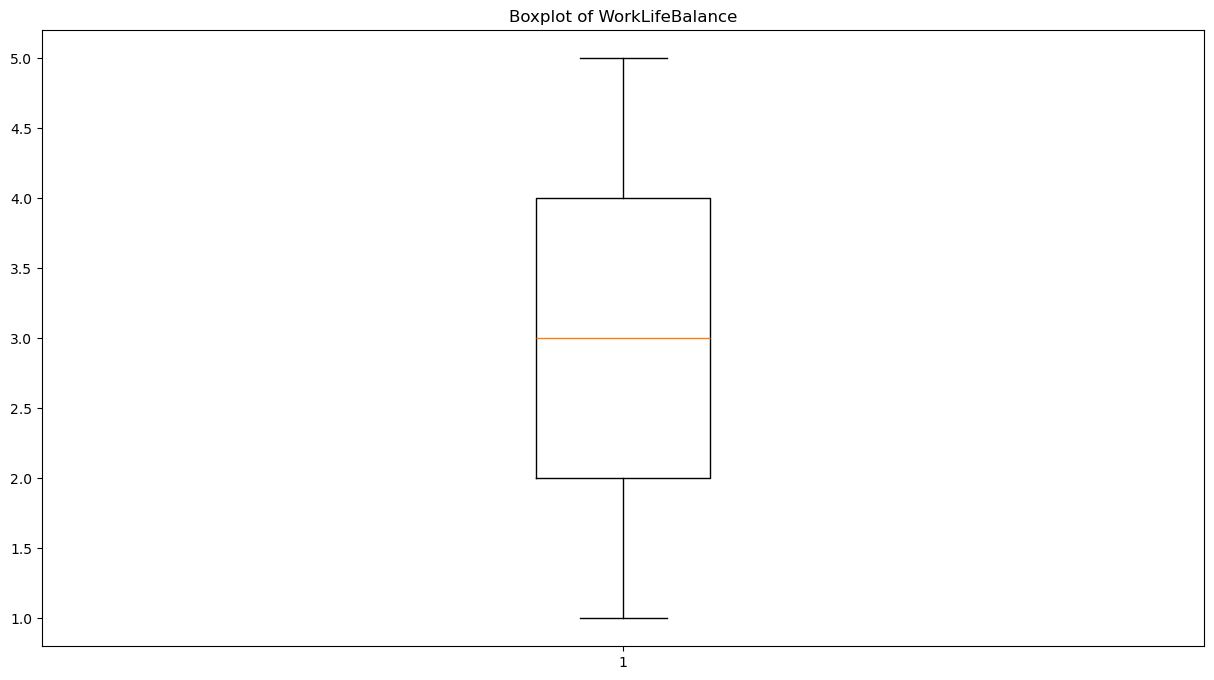

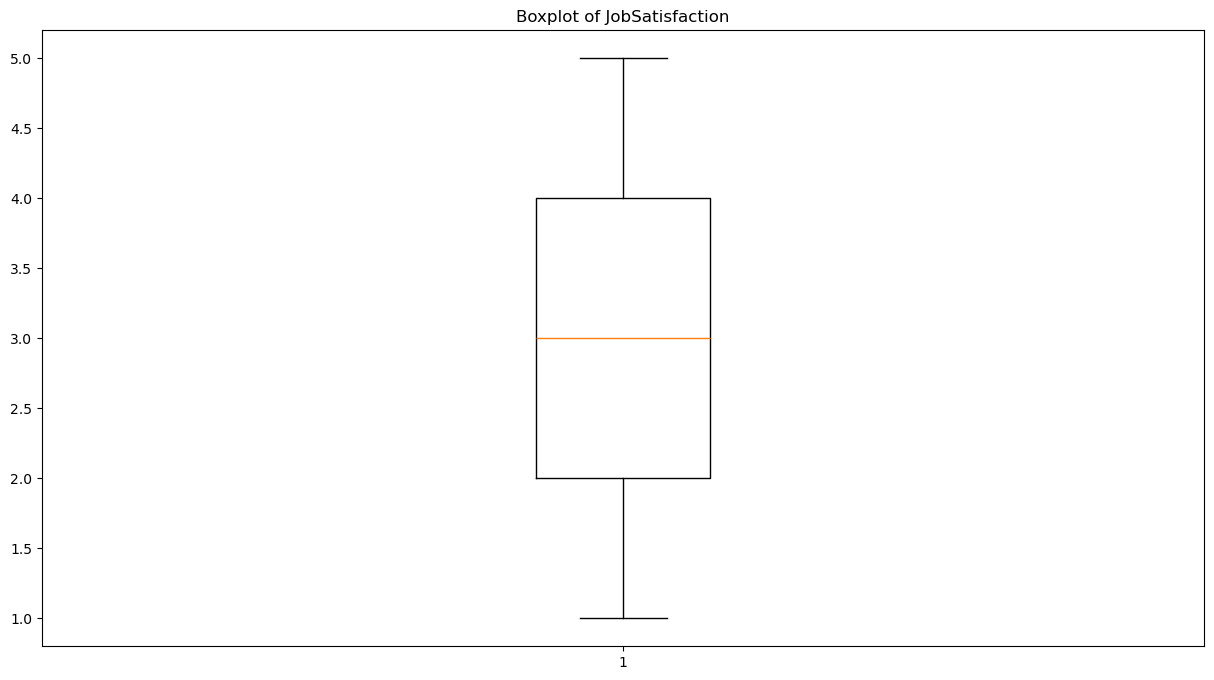

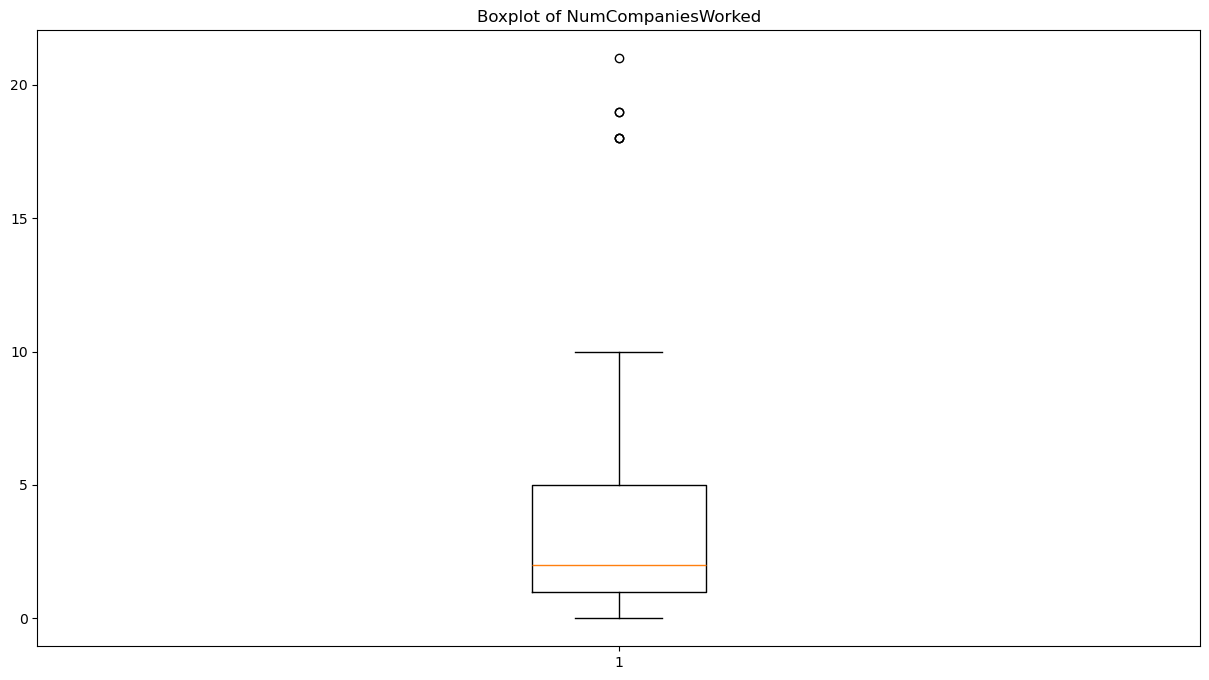

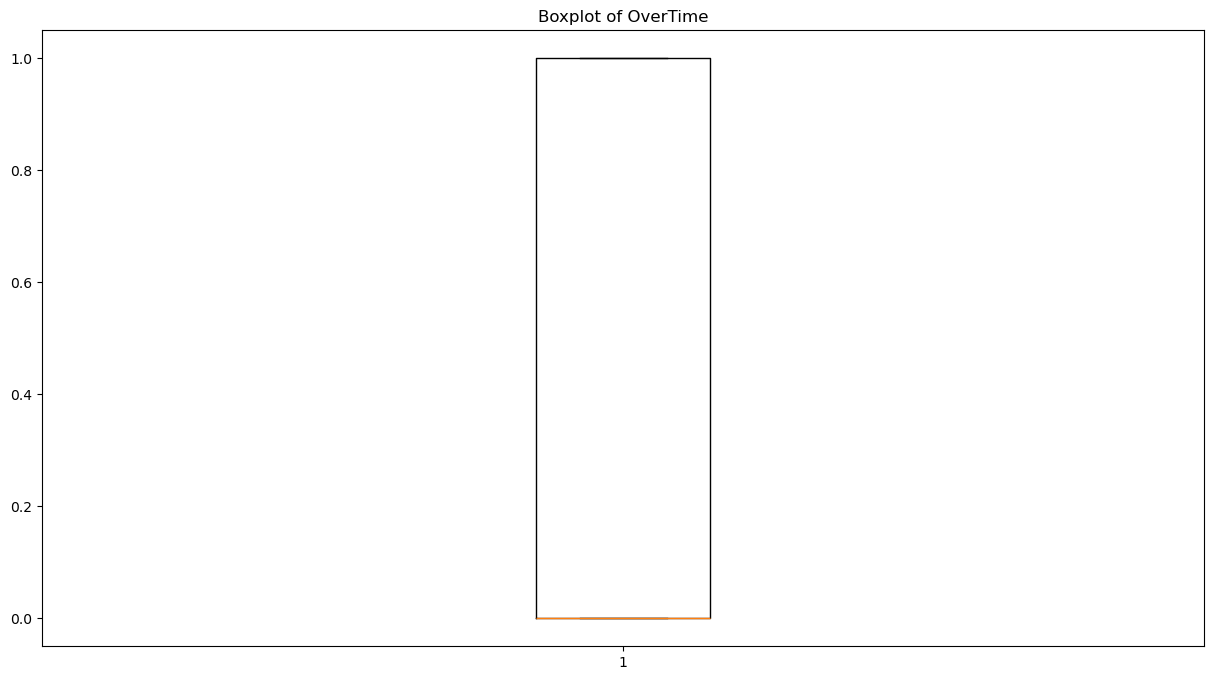

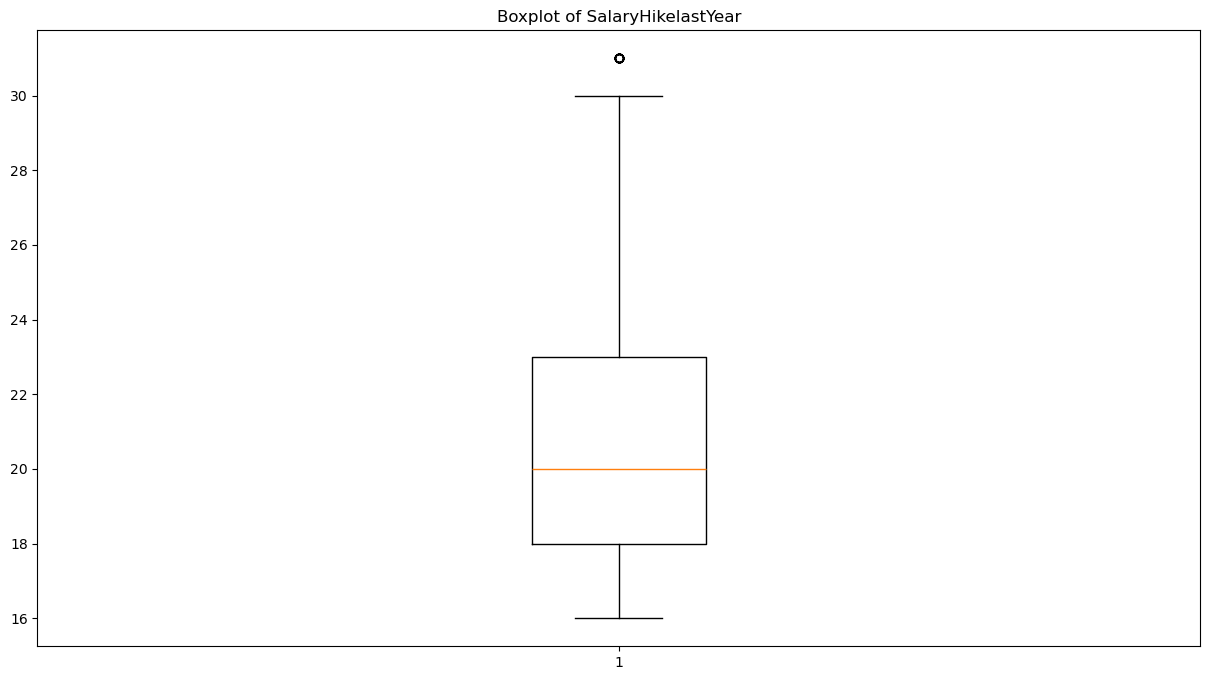

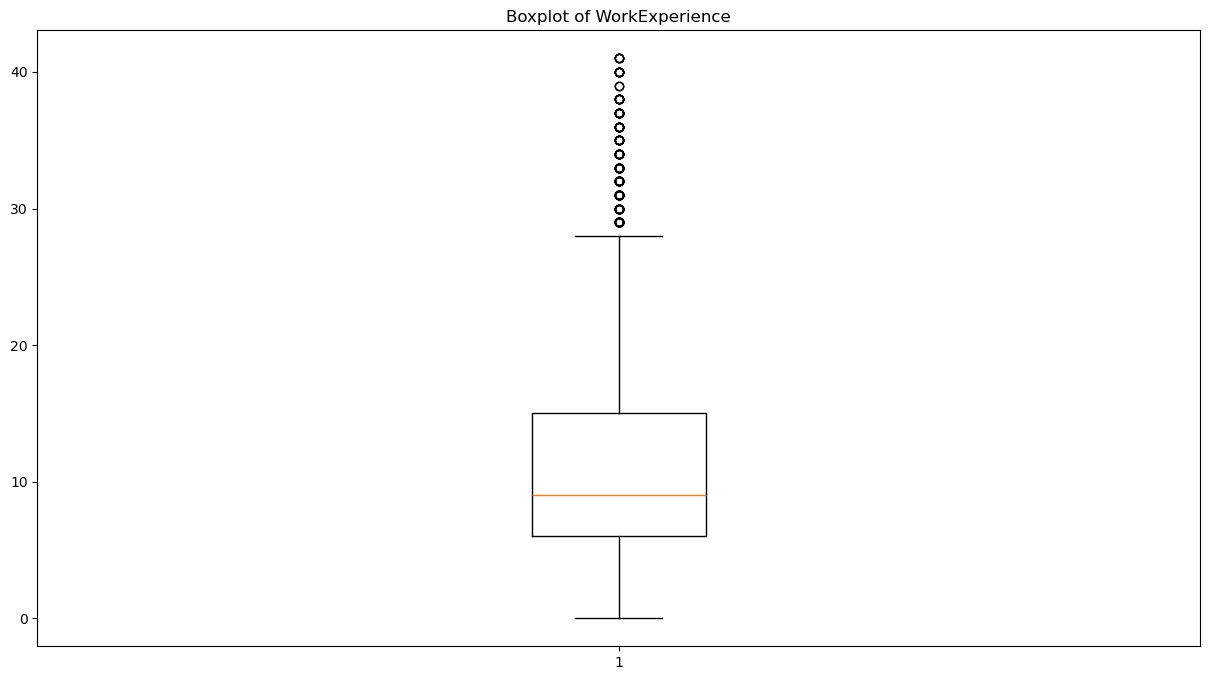

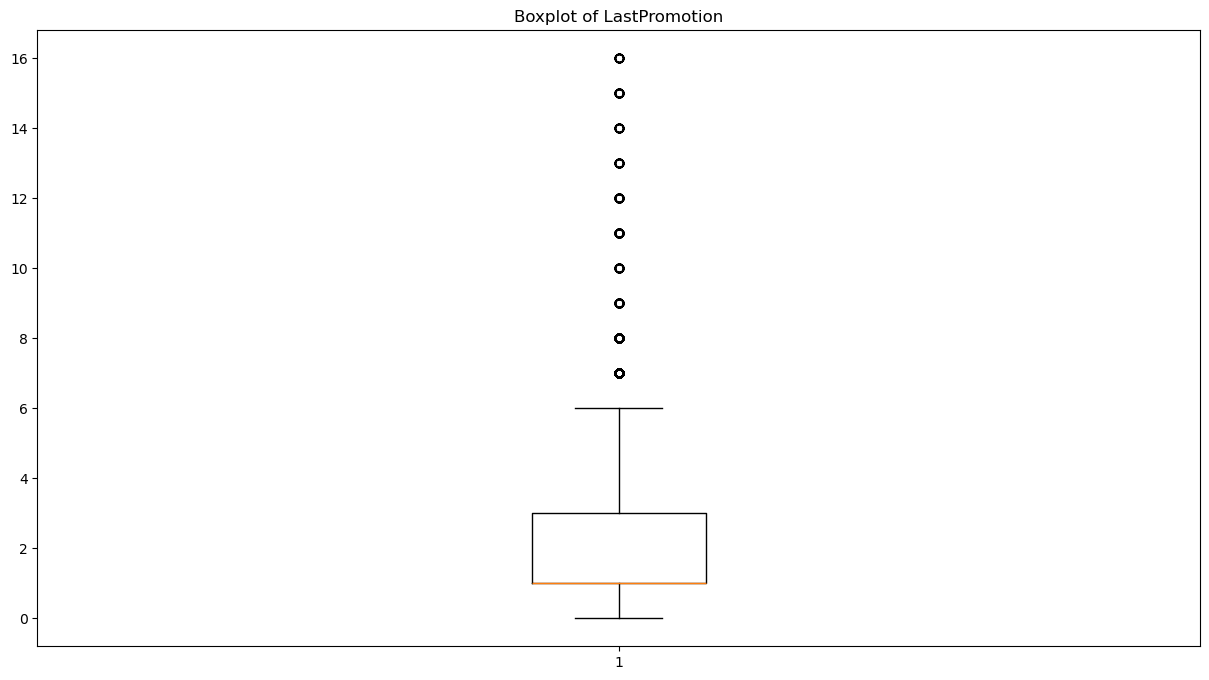

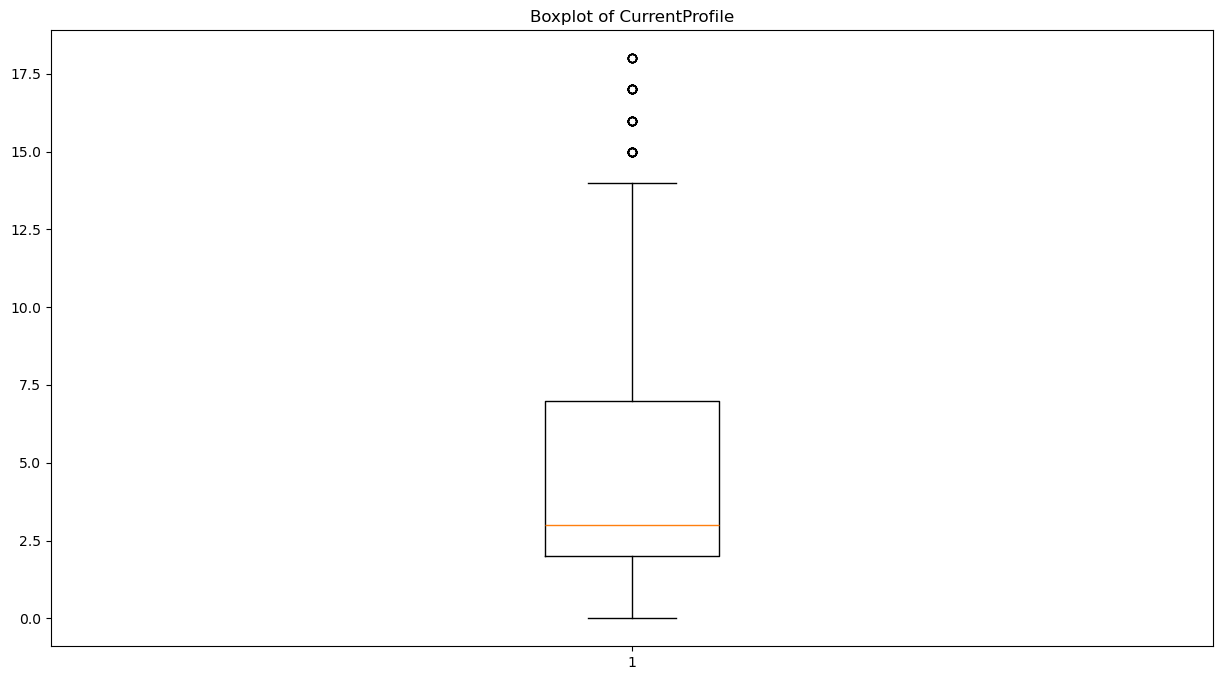

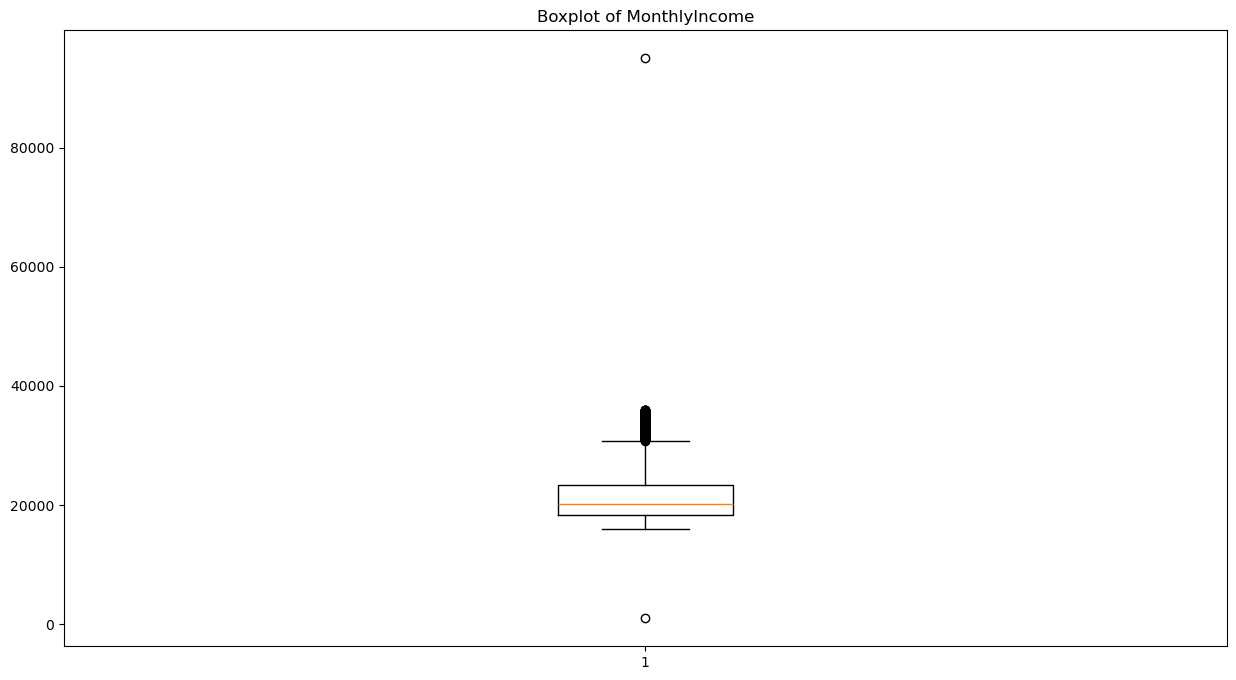

In [27]:
# sns box plots of numeric column 

for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.show()


**Inference**

Outliers: - Income, Experience, Hours/Week

# Outlier Treatment

In [28]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outliers capped using IQR method")


Outliers capped using IQR method


**Outliers are capped rather than being dropped**

In [29]:
# check the categorical columns

cat_cols = df.select_dtypes(exclude='number').columns
cat_cols


Index(['Attrition', 'TravelProfile', 'Department', 'EducationField', 'Gender',
       'Designation', 'ESOPs', 'MaritalStatus'],
      dtype='object')

**Check Unique Values in each categorical Columns**

In [30]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())



Column: Attrition
[0.0 1.0]

Column: TravelProfile
['Rarely' 'Yes' 'No']

Column: Department
['Analytics' 'Sales' 'Marketing']

Column: EducationField
['CA' 'Statistics' 'MBA' 'Marketing Diploma' 'Engineer' 'Other']

Column: Gender
['Male' 'Female']

Column: Designation
['Executive' 'Manager' 'Senior Manager' 'AVP' 'VP']

Column: ESOPs
[1.0 0.0]

Column: MaritalStatus
['M' 'Single' 'Divorsed' 'Married']


**Data Cleaning**

In [31]:
# Gender Columns

df['Gender'] = df['Gender'].replace({'M': 'Male','F': 'Female'})

df['Gender'] = df['Gender'].str.title()


In [32]:
# Marital Status

df['MaritalStatus'] = df['MaritalStatus'].replace({'M': 'Married',
                                                   'S': 'Single',
                                                   'Divorsed': 'Divorced',
                                                   'D': 'Divorced'})

df['MaritalStatus'] = df['MaritalStatus'].str.title()


In [33]:
# Travel Profile

df['TravelProfile'] = df['TravelProfile'].replace({'Yes': 'Frequently','No': 'Rarely'})


In [34]:
df['Department'] = df['Department'].str.title()

df['EducationField'] = df['EducationField'].str.title()


In [35]:
df['EducationField'] = df['EducationField'].replace({'Ca': 'CA','Stats': 'Statistics'})


In [36]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())



Column: Attrition
[0.0 1.0]

Column: TravelProfile
['Rarely' 'Frequently']

Column: Department
['Analytics' 'Sales' 'Marketing']

Column: EducationField
['CA' 'Statistics' 'Mba' 'Marketing Diploma' 'Engineer' 'Other']

Column: Gender
['Male' 'Female']

Column: Designation
['Executive' 'Manager' 'Senior Manager' 'AVP' 'VP']

Column: ESOPs
[1.0 0.0]

Column: MaritalStatus
['Married' 'Single' 'Divorced']


# Encoding

In [37]:
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded.head()

,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,WorkLifeBalance,Designation,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
0,0,35.000000,1,0,5.000000,0,1,69.000000,1.500000,1.000000,1,1.000000,1,1.000000,1.000000,20.000000,7.000000,2.000000,3.000000,1,18932.000000
1,1,32.000000,0,2,5.000000,5,0,62.000000,4.000000,3.000000,1,2.000000,0,8.000000,0.000000,20.000000,4.000000,1.000000,3.000000,2,18785.000000
2,0,31.000000,1,0,5.000000,5,0,45.000000,5.000000,3.000000,2,2.000000,1,3.000000,0.000000,26.000000,12.000000,1.000000,3.000000,2,22091.000000
3,0,34.000000,0,2,10.000000,5,0,32.000000,3.000000,2.000000,2,4.000000,1,1.000000,0.000000,23.000000,5.000000,1.000000,3.000000,0,20302.000000
4,0,37.000000,1,0,27.000000,5,0,49.000000,3.000000,4.000000,2,4.000000,1,8.000000,0.000000,21.000000,12.000000,1.000000,9.000000,0,21674.000000


In [38]:
df_encoded.shape

(5180, 21)

# Train Test Split


In [39]:
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("X_train Shape ",X_train.shape)
print("X_test  Shape ",X_test.shape)

print("Y_train Shape ",y_train.shape)
print("Y_test  Shape ",y_test.shape)

X_train Shape  (4144, 20)
X_test  Shape  (1036, 20)
Y_train Shape  (4144,)
Y_test  Shape  (1036,)


# SMOTE — Handle Imbalance


In [40]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())

print("\nAfter SMOTE:\n", pd.Series(y_train_sm).value_counts())

Before SMOTE:
 Attrition
0    2988
1    1156
Name: count, dtype: int64

After SMOTE:
 Attrition
0    2988
1    2988
Name: count, dtype: int64


# Model Build

**Base Model - Logistic Regression**

In [41]:
# import logistic regression

from sklearn.linear_model import LogisticRegression

# lr

model_lr = LogisticRegression(max_iter=1000)

# fit the model

model_lr.fit(X_train,y_train)


LogisticRegression(max_iter=1000)

In [42]:
# model prediction

y_pred = model_lr.predict(X_test)


# Model Evaluation

In [43]:
# model classification reports

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7915057915057915
[[688  59]
 [157 132]]
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       747
           1       0.69      0.46      0.55       289

    accuracy                           0.79      1036
   macro avg       0.75      0.69      0.71      1036
weighted avg       0.78      0.79      0.78      1036



**Inference**

Model Accuracy is 79%

# Confusion Matrix


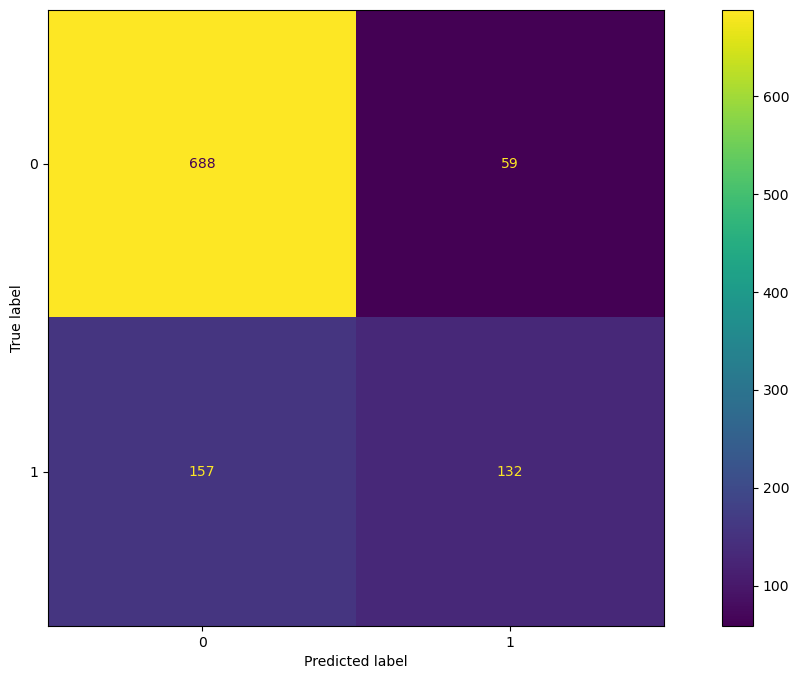

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Decision Tree

**Another Model**

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [46]:
y_pred_dt = dt.predict(X_test)

print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

DT Accuracy: 0.7876447876447876


# Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

In [48]:
rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [49]:
y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.8822393822393823


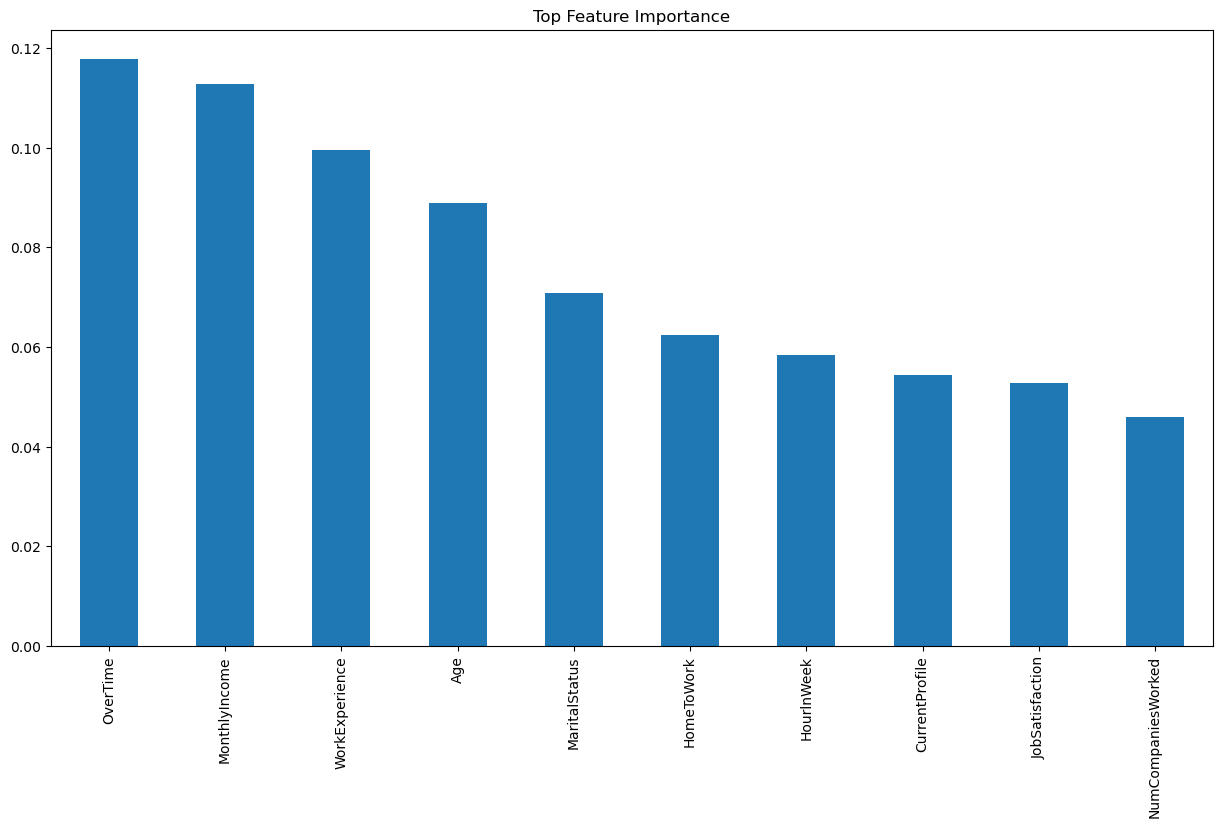

In [50]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10).plot(kind='bar')
plt.title("Top Feature Importance")
plt.show()

# Grid Search Tuning

In [51]:
# grid parameters


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

In [52]:
# model fitting

grid.fit(X_train_sm, y_train_sm)

GridSearchCV(cv=3,
             estimator=RandomForestClassifier(max_depth=8, n_estimators=200,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [53]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [58]:
y_pred_best = gr_best_model.predict(X_test)

y_prob = gr_best_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_best))

print("\nClassification Report:\n", classification_report(y_test, y_pred_))

print("ROC-AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9826254826254827


NameError: name 'y_pred_' is not defined

In [57]:
# Use the predict method instead of calling the model directly

from sklearn.metrics import roc_auc_score


y_pred_best = gr_best_model.predict(X_test)  # Changed from gr_best_model(X_test)

y_prob = gr_best_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_best))

print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

print("ROC-AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9826254826254827

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       747
           1       0.97      0.97      0.97       289

    accuracy                           0.98      1036
   macro avg       0.98      0.98      0.98      1036
weighted avg       0.98      0.98      0.98      1036

ROC-AUC : 0.997135022211105
